# 01 - Exploratory Data Analysis (EDA)

Analisis dataset spam/ham untuk memahami karakteristik data sebelum training model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')
from src.preprocessor import preprocess

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/dataset.csv')

# Pastikan nama kolom sesuai; sesuaikan jika berbeda
# df.columns = ['kategori', 'pesan']  # uncomment jika perlu rename

print("Shape dataset:", df.shape)
print("\nContoh data:")
df.head(10)

Shape dataset: (6415, 2)

Contoh data:


,kategori,pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."
5,spam,"Nnews yang hebat halo, selamat datang di medzo..."
6,spam,Berikut ini adalah permainan panas di Investme...
7,spam,Simpan uang Anda beli untuk mendapatkan barang...
8,spam,Tidak Terkirim: Bisnis Berbasis Rumah Untuk Or...
9,spam,Simpan uang Anda beli untuk mendapatkan barang...


In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplikat ===")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

# Hapus duplikat dan missing value
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"\nJumlah data setelah cleaning: {len(df)}")

=== Missing Values ===
kategori    0
pesan       0
dtype: int64

=== Duplikat ===
Jumlah duplikat: 2653

Jumlah data setelah cleaning: 3762


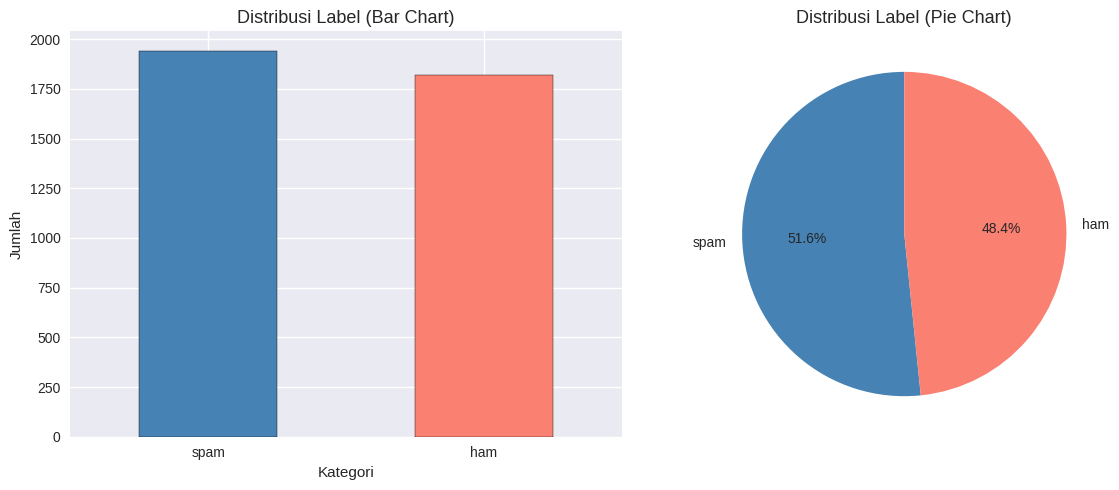

kategori
spam    1942
ham     1820
Name: count, dtype: int64


In [4]:
label_counts = df['kategori'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Distribusi Label (Bar Chart)', fontsize=13)
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(rotation=0)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Distribusi Label (Pie Chart)', fontsize=13)

plt.tight_layout()
plt.savefig('../models/distribusi_label.png', dpi=100)
plt.show()

print(label_counts)

         panjang_pesan                                                         \
                 count     mean      std  min    25%    50%      75%      max   
kategori                                                                        
ham             1820.0  1140.70  1862.56  3.0   87.0  581.5  1490.00  33531.0   
spam            1942.0   995.58  2042.29  6.0  159.0  441.0   959.75  29757.0   

         jumlah_kata                                                  
               count    mean     std  min   25%   50%    75%     max  
kategori                                                              
ham           1820.0  191.61  310.03  1.0  15.0  94.5  253.0  5570.0  
spam          1942.0  161.03  319.38  2.0  24.0  73.0  185.0  4676.0  


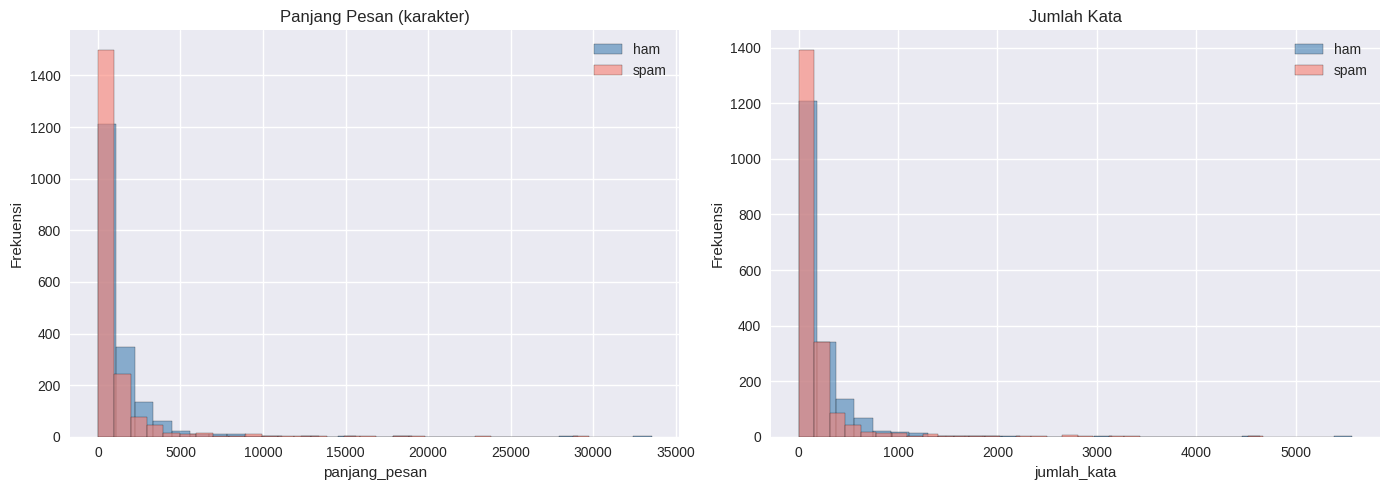

In [5]:
df['panjang_pesan'] = df['pesan'].apply(len)
df['jumlah_kata'] = df['pesan'].apply(lambda x: len(str(x).split()))

print(df.groupby('kategori')[['panjang_pesan', 'jumlah_kata']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['panjang_pesan', 'jumlah_kata'],
                           ['Panjang Pesan (karakter)', 'Jumlah Kata']):
    for label, color in zip(['ham', 'spam'], ['steelblue', 'salmon']):
        subset = df[df['kategori'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.tight_layout()
plt.savefig('../models/distribusi_panjang.png', dpi=100)
plt.show()

In [6]:
df['pesan_bersih'] = df['pesan'].apply(preprocess)

print("Contoh hasil preprocessing:")
for i in range(3):
    print(f"\n[Original ] {df['pesan'].iloc[i]}")
    print(f"[Processed] {df['pesan_bersih'].iloc[i]}")

df.to_csv('../data/dataset_clean.csv', index=False)
print("\nDataset bersih tersimpan di: data/dataset_clean.csv")

Contoh hasil preprocessing:

[Original ] Secara alami tak tertahankan identitas perusahaan Anda sangat sulit untuk mengingat kembali perusahaan: pasar penuh dengan suqestions dan informasi yang sama -sama; Tapi logo yang menarik, statlonery yang bergaya dan situs web yang luar biasa akan membuat tugas lebih mudah. Kami tidak berjanji bahwa Havinq memesan IOGO perusahaan Anda akan secara otomatis menjadi dunia Ieader: itu Isguite Ciear bahwa tanpa produk yang baik, organisasi bisnis yang efektif dan tujuan praktis itu akan menjadi pasar saat ini; Tetapi kami berjanji bahwa upaya pemasaran Anda akan menjadi jauh lebih efektif. Berikut adalah daftar manfaat yang jelas: Kreativitas: Logo asli, buatan tangan, secara khusus dilakukan untuk mencerminkan citra perusahaan Anda yang khas. Kenyamanan: Logo dan alat tulis disediakan dalam semua format; Mudah - untuk - Gunakan sistem manajemen konten Letsyou ubah konten situs web Anda dan bahkan strukturnya. Ketepatan: Anda akan melihat draft logo 